# Convex costs 0.05: RL vs LSM
Out-of-sample comparison of the best v26 agents against the LSM benchmark across convex cost settings. Runs use the monthly swing contract (22 rights) with HHK dynamics; data loaded directly from the logged evaluation CSVs in `logs/<run>/evaluations/`.

In [1]:
from pathlib import Path
import json, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



def find_repo_root() -> Path:

    path = Path.cwd()

    while path != path.parent:

        if (path / ".git").exists():

            return path

        path = path.parent

    raise RuntimeError("Unable to locate repository root")



REPO_ROOT = find_repo_root()

LOGS_DIR = REPO_ROOT / "logs"

RUNS_DIR = REPO_ROOT / "runs"

FIG_DIR = REPO_ROOT / "figs/convex_costs_0p05"

FIG_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option('display.float_format', lambda x: f'{x:,.6f}')

sns.set_theme(style="whitegrid", context="talk")


In [2]:


RUN_SPECS = [

    {"label": "c0_g1_seed11_s29696", "c": 0.0, "gamma": 1.0, "seed": 11, "step": 29696, "run_name": "SwingOption_20_v26_11"},

    {"label": "c0.05_g1_seed11_s26624", "c": 0.05, "gamma": 1.0, "seed": 11, "step": 26624, "run_name": "SwingOption_20_v26_g1_11"},

    {"label": "c0.05_g1.5_seed14_s27648", "c": 0.05, "gamma": 1.5, "seed": 14, "step": 27648, "run_name": "SwingOption_20_v26_g1.5_14"},

    {"label": "c0.05_g2_seed14_s26624", "c": 0.05, "gamma": 2.0, "seed": 14, "step": 26624, "run_name": "SwingOption_20_v26_g2_14"},

]



def attach_paths(spec: dict) -> dict:

    spec = spec.copy()

    eval_dir = LOGS_DIR / spec["run_name"] / "evaluations"

    spec["rl_path"] = eval_dir / f"rl_episode_{spec['step']}.csv"

    spec["lsm_path"] = eval_dir / "lsm.csv"

    spec["config_path"] = RUNS_DIR / f"{spec['run_name']}.json"

    return spec



RUN_SPECS = [attach_paths(s) for s in RUN_SPECS]

pd.DataFrame(RUN_SPECS)[["label", "c", "gamma", "seed", "step", "run_name"]]



,label,c,gamma,seed,step,run_name
0,c0_g1_seed11_s29696,0.000000,1.000000,11,29696,SwingOption_20_v26_11
1,c0.05_g1_seed11_s26624,0.050000,1.000000,11,26624,SwingOption_20_v26_g1_11
2,c0.05_g1.5_seed14_s27648,0.050000,1.500000,14,27648,SwingOption_20_v26_g1.5_14
3,c0.05_g2_seed14_s26624,0.050000,2.000000,14,26624,SwingOption_20_v26_g2_14


In [3]:
RL_REQUIRED = ["path", "time_step", "q_t", "reward", "exercise_cost", "spot_minus_strike", "spot"]
LSM_REQUIRED = ["path", "time_step", "q_t", "payoff", "payoff_gross", "exercise_cost", "spot"]


def discount_factor(time_steps, cfg):
    dt = cfg["maturity"] / cfg["n_rights"]
    return np.exp(-cfg["risk_free_rate"] * (time_steps + 1) * dt)


def load_eval_csv(path: Path, required_cols, name: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    missing = [c for c in required_cols if c not in df.columns]
    assert not missing, f"{name} missing columns: {missing}"
    assert len(df) > 0, f"{name} is empty"
    na_cols = df.columns[df.isna().any()]
    assert len(na_cols) == 0, f"{name} has NaNs in {list(na_cols)}"
    return df


def per_path_metrics(df: pd.DataFrame, cfg: dict, method: str) -> pd.DataFrame:
    df = df.copy()
    df["discount"] = discount_factor(df["time_step"], cfg)
    if method == "RL":
        df["net_step"] = df["reward"]
        df["cost_step"] = df["exercise_cost"] * df["discount"]
        df["gross_step"] = df["net_step"] + df["cost_step"]
        gross_recon = np.maximum(df["spot_minus_strike"], 0.0) * df["q_t"] * df["discount"]
        max_gap = float(np.abs(gross_recon - df["gross_step"]).max())
        assert max_gap < 5e-3, f"RL reward/cost alignment off by {max_gap:.4f}"
    else:
        df["net_step"] = df["payoff"] * df["discount"]
        df["cost_step"] = df["exercise_cost"] * df["discount"]
        if "payoff_gross" in df.columns:
            assert np.allclose(df["payoff"] + df["exercise_cost"], df["payoff_gross"], atol=1e-6)
            df["gross_step"] = df["payoff_gross"] * df["discount"]
        else:
            df["gross_step"] = df["net_step"] + df["cost_step"]
    first = df.loc[df["q_t"] > 1e-8].groupby("path")["time_step"].min().rename("first_ex")
    grouped = (
        df.groupby("path", as_index=False)
        .agg(
            net_pv=("net_step", "sum"),
            gross_pv=("gross_step", "sum"),
            cost=("cost_step", "sum"),
            qty=("q_t", "sum"),
            max_step=("time_step", "max"),
        )
        .merge(first, on="path", how="left")
    )
    grouped["method"] = method
    return grouped


def per_step_profile(df: pd.DataFrame, cfg: dict) -> pd.DataFrame:
    idx = pd.MultiIndex.from_product(
        [sorted(df["path"].unique()), range(cfg["n_rights"])], names=["path", "time_step"]
    )
    q_full = df.set_index(["path", "time_step"])["q_t"].reindex(idx, fill_value=0.0)
    return q_full.groupby("time_step").mean().reset_index(name="q_mean")


def summary_stats(g: pd.DataFrame) -> pd.Series:
    n = len(g)
    def stat(col):
        arr = g[col].values
        mean = arr.mean()
        sd = arr.std(ddof=1)
        se = sd / math.sqrt(n)
        return mean, sd, se

    pv_m, pv_sd, pv_se = stat("net_pv")
    cost_m, cost_sd, cost_se = stat("cost")
    gross_m, gross_sd, gross_se = stat("gross_pv")
    qty_m, qty_sd, qty_se = stat("qty")
    return pd.Series(
        {
            "paths": n,
            "pv_mean": pv_m,
            "pv_std": pv_sd,
            "pv_se": pv_se,
            "cost_mean": cost_m,
            "cost_se": cost_se,
            "gross_mean": gross_m,
            "gross_se": gross_se,
            "qty_mean": qty_m,
            "qty_se": qty_se,
        }
    )


def savefig(fig, name: str, close_fig: bool = False):
    for ext in ("png", "pdf"):
        fig.savefig(FIG_DIR / f"{name}.{ext}", bbox_inches="tight", dpi=300)
    if close_fig:
        plt.close(fig)


In [4]:
from typing import Dict

def load_and_prepare(spec: dict) -> Dict[str, object]:
    assert spec["rl_path"].exists(), f"Missing RL eval: {spec['rl_path']}"
    assert spec["lsm_path"].exists(), f"Missing LSM eval: {spec['lsm_path']}"
    with open(spec["config_path"]) as f:
        cfg = json.load(f)
    assert abs(cfg["c_cost"] - spec["c"]) < 1e-9, "c mismatch"
    assert abs(cfg["gamma_cost"] - spec["gamma"]) < 1e-9, "gamma mismatch"
    assert cfg["seed"] == spec["seed"], "seed mismatch"

    rl_df = load_eval_csv(spec["rl_path"], RL_REQUIRED, f"RL {spec['label']}")
    lsm_df = load_eval_csv(spec["lsm_path"], LSM_REQUIRED, f"LSM {spec['label']}")

    n_paths = cfg.get("n_paths_eval", rl_df["path"].nunique())
    assert rl_df["path"].nunique() == lsm_df["path"].nunique() == n_paths
    assert set(rl_df["path"]) == set(lsm_df["path"])
    assert lsm_df.shape[0] == n_paths * cfg["n_rights"], "LSM grid not full"

    rl_paths = per_path_metrics(rl_df, cfg, "RL")
    lsm_paths = per_path_metrics(lsm_df, cfg, "LSM")
    merged = rl_paths.merge(lsm_paths, on="path", suffixes=("_rl", "_lsm"))
    assert merged.shape[0] == n_paths, "Path alignment mismatch"
    optional_cols = [c for c in merged.columns if "first_ex" in c]
    core_na = merged.drop(columns=optional_cols).isna().sum().sum()
    assert core_na == 0, "Merged frame has NaNs outside first_ex"

    merged["delta_pv"] = merged["net_pv_rl"] - merged["net_pv_lsm"]
    merged["delta_cost"] = merged["cost_rl"] - merged["cost_lsm"]
    merged["delta_gross"] = merged["gross_pv_rl"] - merged["gross_pv_lsm"]
    merged["delta_qty"] = merged["qty_rl"] - merged["qty_lsm"]

    profiles = []
    for method, frame in (("RL", rl_df), ("LSM", lsm_df)):
        prof = per_step_profile(frame, cfg)
        prof["method"] = method
        profiles.append(prof)
    profile_df = pd.concat(profiles, ignore_index=True)

    meta = {k: spec[k] for k in ("label", "c", "gamma", "seed", "step", "run_name")}
    for frame in (rl_paths, lsm_paths, merged, profile_df):
        for k, v in meta.items():
            frame[k] = v

    paths = pd.concat([rl_paths, lsm_paths], ignore_index=True)
    return {
        "spec": spec,
        "cfg": cfg,
        "rl_df": rl_df,
        "lsm_df": lsm_df,
        "paths": paths,
        "merged": merged,
        "profile": profile_df,
        "n_paths": n_paths,
    }


run_data = []
paths_all = []
merged_all = []
profiles_all = []
for spec in RUN_SPECS:
    data = load_and_prepare(spec)
    run_data.append(data)
    paths_all.append(data["paths"])
    merged_all.append(data["merged"])
    profiles_all.append(data["profile"])

paths_all_df = pd.concat(paths_all, ignore_index=True)
merged_all_df = pd.concat(merged_all, ignore_index=True)
profiles_all_df = pd.concat(profiles_all, ignore_index=True)

# Quick sanity: eval grids and NaNs
row_sanity = (
    paths_all_df.groupby("label")["path"].count()
    .rename("rows")
    .to_frame()
    .assign(unique_paths=lambda t: t.index.map(lambda lbl: int(paths_all_df.query('label == @lbl')['path'].nunique())))
)
row_sanity


AssertionError: Missing RL eval: /Users/alexanderithakis/Documents/GitHub/DRL-Swing-Options/logs/SwingOption_20_v26_11/evaluations/rl_episode_29696.csv

In [ ]:
del row_sanity

: 

: 

: 

In [ ]:

summary_methods = (
    paths_all_df
    .groupby(["label", "c", "gamma", "seed", "step", "method"], group_keys=False)
    .apply(summary_stats, include_groups=False)
    .reset_index()
)

lsm_lookup = summary_methods.query("method == 'LSM'").set_index("label")["pv_mean"].to_dict()

delta_summary = (
    merged_all_df
    .groupby(["label", "c", "gamma", "seed", "step"], group_keys=False)
    .apply(
        lambda g: pd.Series(
            {
                "paths": len(g),
                "delta_pv_mean": g["delta_pv"].mean(),
                "delta_pv_std": g["delta_pv"].std(ddof=1),
                "delta_pv_se": g["delta_pv"].std(ddof=1) / math.sqrt(len(g)),
                "delta_cost_mean": g["delta_cost"].mean(),
                "delta_gross_mean": g["delta_gross"].mean(),
                "delta_qty_mean": g["delta_qty"].mean(),
            }
        ),
        include_groups=False,
    )
    .reset_index()
)

delta_summary["delta_pct_vs_lsm"] = delta_summary.apply(
    lambda r: r["delta_pv_mean"] / lsm_lookup[r["label"]], axis=1
)
delta_summary["delta_pct_se"] = delta_summary.apply(
    lambda r: r["delta_pv_se"] / lsm_lookup[r["label"]], axis=1
)

summary_methods.sort_values(["c", "gamma", "method"])[
    ["label", "method", "pv_mean", "pv_se", "cost_mean", "qty_mean"]
]


,label,method,pv_mean,pv_se,cost_mean,qty_mean
6,c0_g1_seed11_s29696,LSM,2.646823,0.030890,0.000000,11.436035
7,c0_g1_seed11_s29696,RL,2.614747,0.030347,0.000000,11.495047
2,c0.05_g1_seed11_s26624,LSM,2.113744,0.029001,0.492258,9.871338
3,c0.05_g1_seed11_s26624,RL,2.101129,0.028524,0.483064,9.686322
0,c0.05_g1.5_seed14_s27648,LSM,1.941281,0.027627,0.655817,9.299805
1,c0.05_g1.5_seed14_s27648,RL,1.971224,0.027621,0.592553,9.386370
4,c0.05_g2_seed14_s26624,LSM,1.695675,0.026656,0.833205,8.354980
5,c0.05_g2_seed14_s26624,RL,1.832268,0.026412,0.658621,9.395399


: 

: 

: 

In [ ]:

summary_methods


,label,c,gamma,seed,step,method,paths,pv_mean,pv_std,pv_se,cost_mean,cost_se,gross_mean,gross_se,qty_mean,qty_se
0,c0.05_g1.5_seed14_s27648,0.050000,1.500000,14,27648,LSM,"8,192.000000",1.941281,2.500551,0.027627,0.655817,0.006131,2.597098,0.032666,9.299805,0.086939
1,c0.05_g1.5_seed14_s27648,0.050000,1.500000,14,27648,RL,"8,192.000000",1.971224,2.499974,0.027621,0.592553,0.005525,2.563777,0.032196,9.386370,0.086425
2,c0.05_g1_seed11_s26624,0.050000,1.000000,11,26624,LSM,"8,192.000000",2.113744,2.624838,0.029001,0.492258,0.004381,2.606002,0.032531,9.871338,0.087838
3,c0.05_g1_seed11_s26624,0.050000,1.000000,11,26624,RL,"8,192.000000",2.101129,2.581653,0.028524,0.483064,0.004323,2.584193,0.032052,9.686322,0.086684
4,c0.05_g2_seed14_s26624,0.050000,2.000000,14,26624,LSM,"8,192.000000",1.695675,2.412647,0.026656,0.833205,0.008557,2.528880,0.033866,8.354980,0.085792
5,c0.05_g2_seed14_s26624,0.050000,2.000000,14,26624,RL,"8,192.000000",1.832268,2.390532,0.026412,0.658621,0.006386,2.490890,0.031784,9.395399,0.084138
6,c0_g1_seed11_s29696,0.000000,1.000000,11,29696,LSM,"8,192.000000",2.646823,2.795820,0.030890,0.000000,0.000000,2.646823,0.030890,11.436035,0.086362
7,c0_g1_seed11_s29696,0.000000,1.000000,11,29696,RL,"8,192.000000",2.614747,2.746732,0.030347,0.000000,0.000000,2.614747,0.030347,11.495047,0.087696


: 

: 

: 

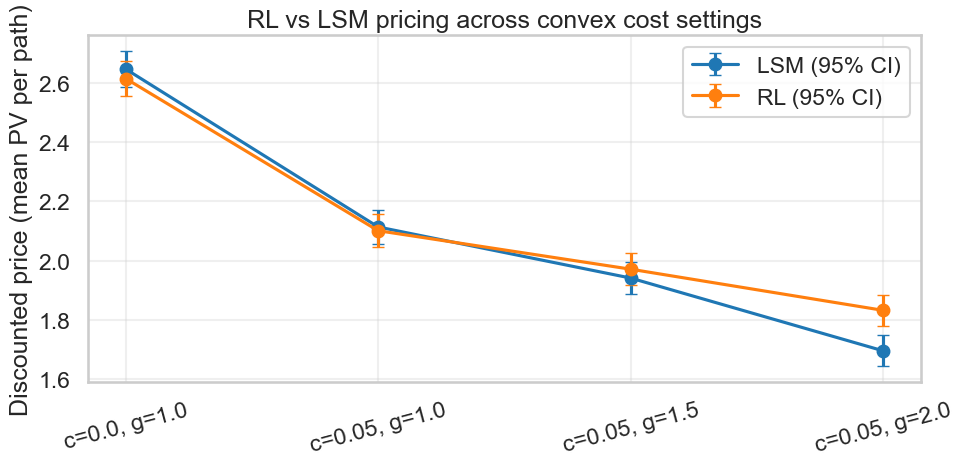

: 

: 

: 

In [ ]:

order = [spec["label"] for spec in RUN_SPECS]
label_map = {spec["label"]: f"c={spec['c']}, g={spec['gamma']}" for spec in RUN_SPECS}

fig, ax = plt.subplots(figsize=(10, 5))
colors = {"RL": "tab:orange", "LSM": "tab:blue"}
for method in ["LSM", "RL"]:
    subset = summary_methods.query("method == @method").set_index("label").loc[order].reset_index()
    ax.errorbar(
        range(len(order)),
        subset["pv_mean"],
        yerr=1.96 * subset["pv_se"],
        fmt="o-",
        color=colors[method],
        label=f"{method} (95% CI)",
        capsize=4,
    )
ax.set_xticks(range(len(order)))
ax.set_xticklabels([label_map[o] for o in order], rotation=15)
ax.set_ylabel("Discounted price (mean PV per path)")
ax.set_title("RL vs LSM pricing across convex cost settings")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
# savefig(fig, "price_comparison")
plt.show()
plt.close(fig)

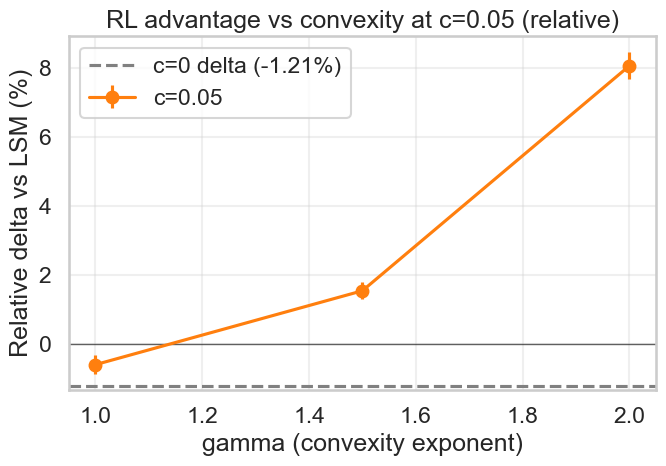

: 

: 

: 

In [ ]:

fig, ax = plt.subplots(figsize=(7, 5))
c005 = delta_summary.query("c == 0.05").sort_values("gamma")
rel_vals = c005["delta_pct_vs_lsm"] * 100
rel_err = 1.96 * c005["delta_pct_se"] * 100
ax.errorbar(
    c005["gamma"], rel_vals, yerr=rel_err, fmt="o-", color="tab:orange", label="c=0.05"
)
base = delta_summary.query("c == 0.0")
if not base.empty:
    base_rel = float(base["delta_pct_vs_lsm"].iloc[0]) * 100
    ax.axhline(base_rel, color="gray", linestyle="--", label=f"c=0 delta ({base_rel:.2f}%)")
ax.axhline(0, color="black", linewidth=1, alpha=0.6)
ax.set_xlabel("gamma (convexity exponent)")
ax.set_ylabel("Relative delta vs LSM (%)")
ax.set_title("RL advantage vs convexity at c=0.05 (relative)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
# savefig(fig, "delta_vs_gamma")
plt.show()
plt.close(fig)

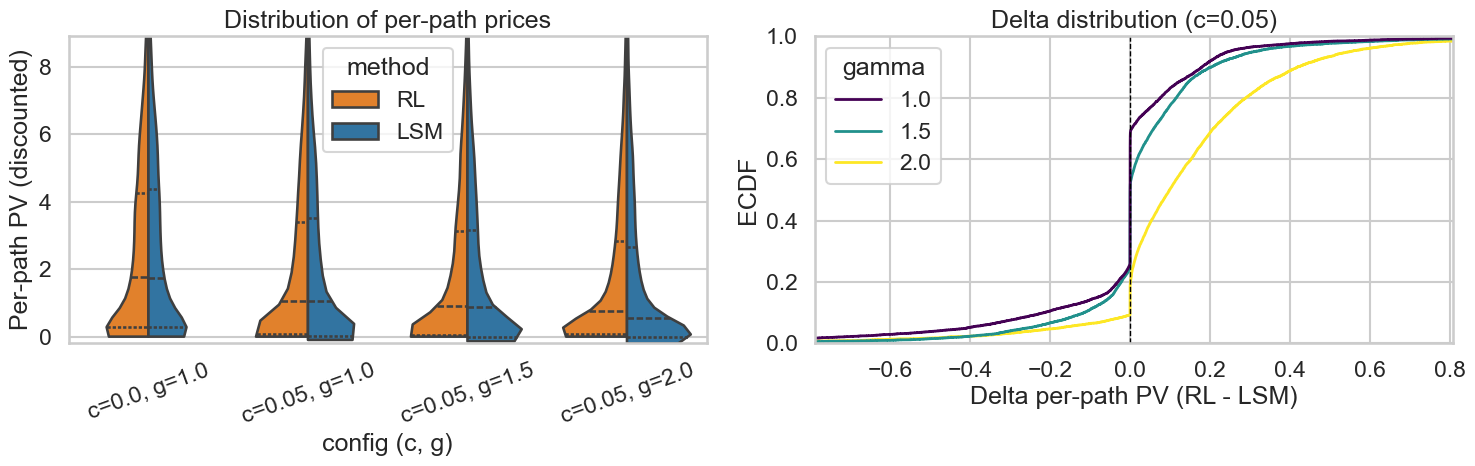

: 

: 

: 

In [ ]:

paths_all_df["config"] = paths_all_df.apply(lambda r: f"c={r['c']}, g={r['gamma']}", axis=1)
config_order = [label_map[o] for o in order]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Limit violin y-range to 0-98th percentile to de-emphasize tails
pv_lo, pv_hi = np.percentile(paths_all_df["net_pv"], [0, 98])

sns.violinplot(
    data=paths_all_df,
    x="config",
    y="net_pv",
    hue="method",
    order=config_order,
    palette={"RL": "tab:orange", "LSM": "tab:blue"},
    split=True,
    cut=0,
    inner="quartile",
    ax=axes[0],
)
axes[0].set_xlabel("config (c, g)")
axes[0].set_ylabel("Per-path PV (discounted)")
axes[0].set_title("Distribution of per-path prices")
axes[0].tick_params(axis="x", rotation=20)
axes[0].set_ylim(pv_lo, pv_hi)

c005_delta = merged_all_df.query("c == 0.05").copy()
delta_lo, delta_hi = np.percentile(c005_delta["delta_pv"], [1, 99])

sns.ecdfplot(
    data=c005_delta,
    x="delta_pv",
    hue="gamma",
    palette="viridis",
    linewidth=2,
    ax=axes[1],
)
axes[1].axvline(0, color="black", linestyle="--", linewidth=1)
axes[1].set_xlabel("Delta per-path PV (RL - LSM)")
axes[1].set_ylabel("ECDF")
axes[1].set_title("Delta distribution (c=0.05)")
handles, labels = axes[1].get_legend_handles_labels()
if handles:
    axes[1].legend(handles=handles, labels=labels, title="gamma")
axes[1].set_xlim(delta_lo, delta_hi)

plt.tight_layout()
# savefig(fig, "distribution_panels")
plt.show()
plt.close(fig)

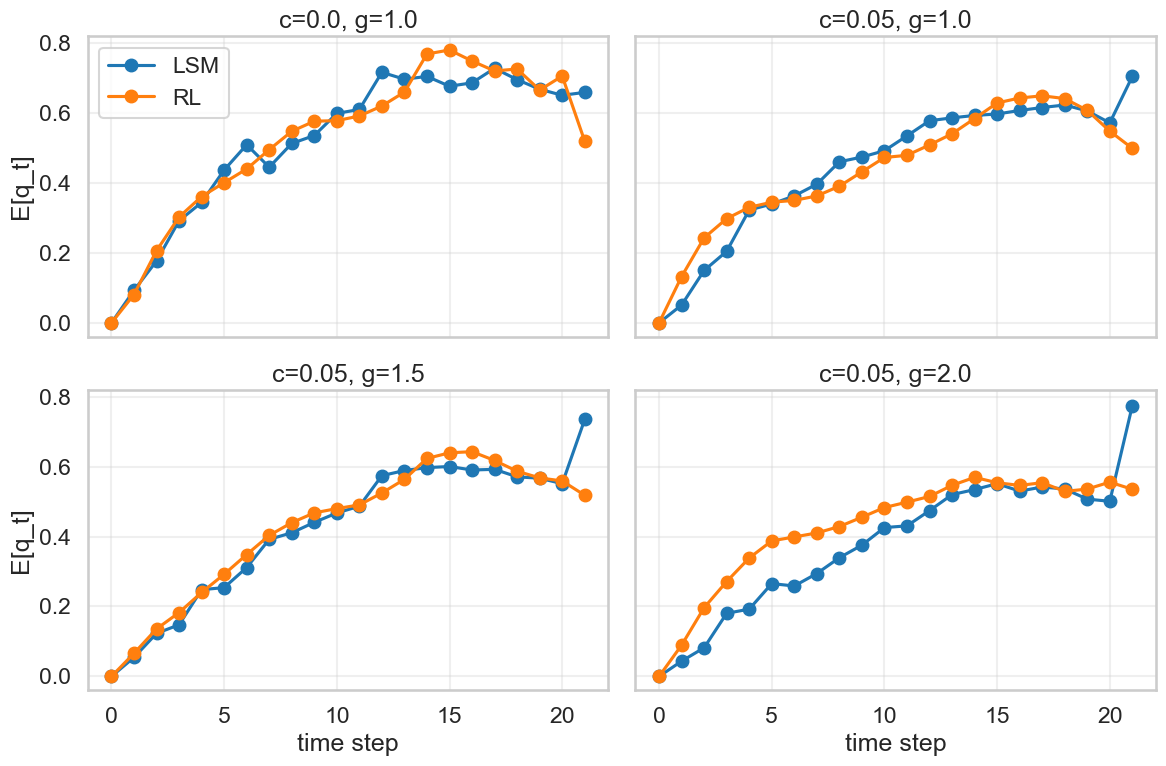

: 

: 

: 

In [ ]:

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
axes = axes.ravel()
for ax, lbl in zip(axes, order):
    sub = profiles_all_df.query("label == @lbl")
    for method, color in (("LSM", "tab:blue"), ("RL", "tab:orange")):
        prof = sub.query("method == @method")
        ax.plot(prof["time_step"], prof["q_mean"], marker="o", label=method, color=color)
    ax.set_title(label_map[lbl])
    ax.grid(alpha=0.3)
axes[0].set_ylabel("E[q_t]")
axes[2].set_ylabel("E[q_t]")
axes[2].set_xlabel("time step")
axes[3].set_xlabel("time step")
axes[0].legend()
plt.tight_layout()
# savefig(fig, "exercise_profile")
plt.show()
plt.close(fig)

## Cost decomposition and distributions across configs

In [ ]:

# Per-path stats with cost/gross/net decomposition
path_stats = paths_all_df.copy()
path_stats["config"] = path_stats["label"].map(label_map)
path_stats = path_stats.rename(
    columns={
        "net_pv": "PV_net",
        "gross_pv": "PV_gross",
        "cost": "PV_cost",
        "qty": "Q_total",
    }
)
path_stats["cost_per_unit"] = np.where(path_stats["Q_total"] > 0, path_stats["PV_cost"] / path_stats["Q_total"], np.nan)
q1, q99 = np.nanpercentile(path_stats["cost_per_unit"].dropna(), [1, 99])
path_stats["cost_per_unit_clipped"] = path_stats["cost_per_unit"].clip(q1, q99)

summary_df = (
    path_stats
    .groupby(["config", "label", "method"], as_index=False)
    .agg(
        PV_gross_mean=("PV_gross", "mean"),
        PV_cost_mean=("PV_cost", "mean"),
        PV_net_mean=("PV_net", "mean"),
        cost_per_unit_mean=("cost_per_unit", "mean"),
        paths=("path", "count"),
    )
)
summary_df


,config,label,method,PV_gross_mean,PV_cost_mean,PV_net_mean,cost_per_unit_mean,paths
0,"c=0.0, g=1.0",c0_g1_seed11_s29696,LSM,2.646823,0.000000,2.646823,0.000000,8192
1,"c=0.0, g=1.0",c0_g1_seed11_s29696,RL,2.614747,0.000000,2.614747,0.000000,8192
2,"c=0.05, g=1.0",c0.05_g1_seed11_s26624,LSM,2.606002,0.492258,2.113744,0.049866,8192
3,"c=0.05, g=1.0",c0.05_g1_seed11_s26624,RL,2.584193,0.483064,2.101129,0.049874,8192
4,"c=0.05, g=1.5",c0.05_g1.5_seed14_s27648,LSM,2.597098,0.655817,1.941281,0.070516,8192
5,"c=0.05, g=1.5",c0.05_g1.5_seed14_s27648,RL,2.563777,0.592553,1.971224,0.060732,8192
6,"c=0.05, g=2.0",c0.05_g2_seed14_s26624,LSM,2.528880,0.833205,1.695675,0.099718,8192
7,"c=0.05, g=2.0",c0.05_g2_seed14_s26624,RL,2.490890,0.658621,1.832268,0.058488,8192


: 

: 

: 

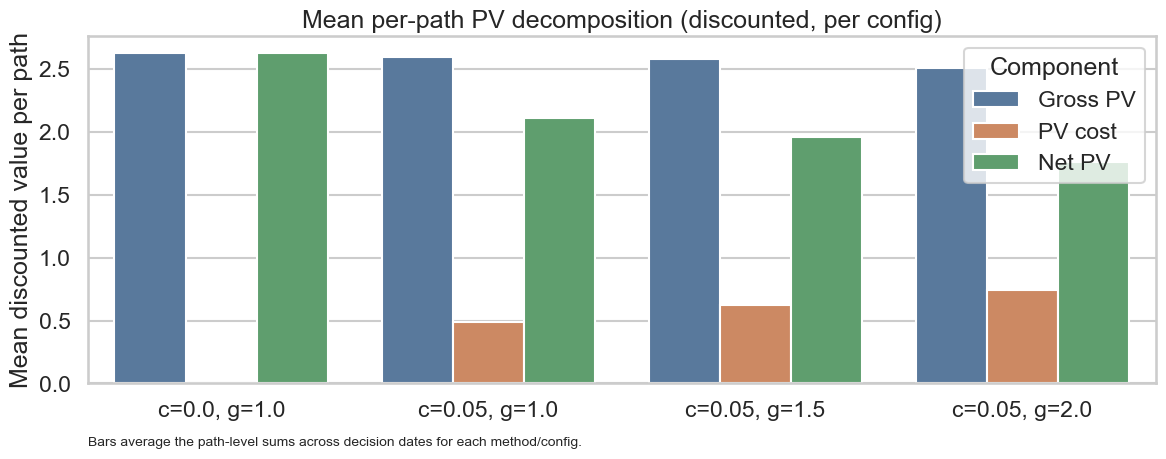

: 

: 

: 

In [ ]:

# Mean PV decomposition per config/method
component_map = {
    "PV_gross_mean": "Gross PV",
    "PV_cost_mean": "PV cost",
    "PV_net_mean": "Net PV",
}
component_colors = {"Gross PV": "#4e79a7", "PV cost": "#dd8452", "Net PV": "#55a868"}

decomp = (
    summary_df
    .melt(id_vars=["config", "label", "method", "paths"], value_vars=list(component_map.keys()), var_name="component", value_name="value")
    .assign(component=lambda d: d["component"].map(component_map))
)
fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=decomp, x="config", y="value", hue="component", palette=component_colors, ax=ax, errorbar=None)
ax.set_title("Mean per-path PV decomposition (discounted, per config)")
ax.set_xlabel("")
ax.set_ylabel("Mean discounted value per path")
ax.tick_params(axis="x", rotation=0)
ax.legend(title="Component", loc="upper left")
annot = "Bars average the path-level sums across decision dates for each method/config."
ax.annotate(annot, xy=(0, -0.18), xycoords="axes fraction", fontsize=10)
plt.tight_layout()
# savefig(fig, "cost_decomposition_all")
plt.show()
plt.close(fig)

In [ ]:
del summary_df

: 

: 

: 

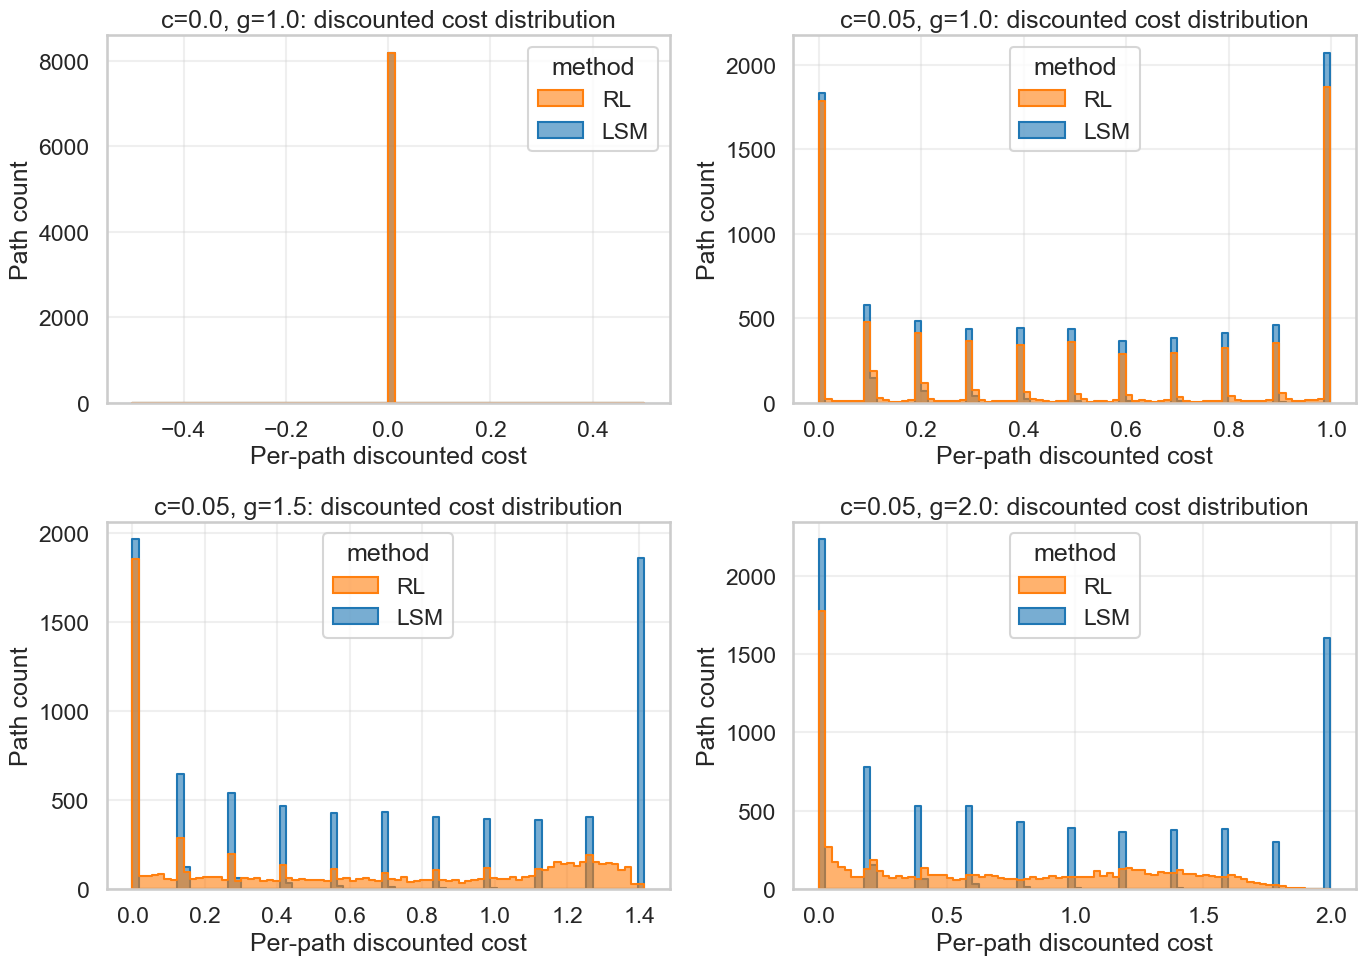

: 

: 

: 

In [ ]:

# Per-path cost distribution by config
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=False, sharey=False)
axes = axes.ravel()
cost_counts = []
for ax, lbl in zip(axes, order):
    cfg_name = label_map[lbl]
    sub = path_stats.query("label == @lbl")
    count_lsm = sub.loc[sub["method"] == "LSM", "PV_cost"].nunique()
    count_rl = sub.loc[sub["method"] == "RL", "PV_cost"].nunique()
    cost_counts.append((cfg_name, count_lsm, count_rl))
    sns.histplot(
        data=sub,
        x="PV_cost",
        hue="method",
        bins=80,
        palette={"RL": "tab:orange", "LSM": "tab:blue"},
        ax=ax,
        element="step",
        stat="count",
        alpha=0.6,
    )
    ax.set_title(f"{cfg_name}: discounted cost distribution")
    ax.set_xlabel("Per-path discounted cost")
    ax.set_ylabel("Path count")
    ax.grid(alpha=0.3)
fig.tight_layout()
# savefig(fig, "cost_histograms_by_config")
plt.show()
plt.close(fig)

## Cost diagnostics across configs

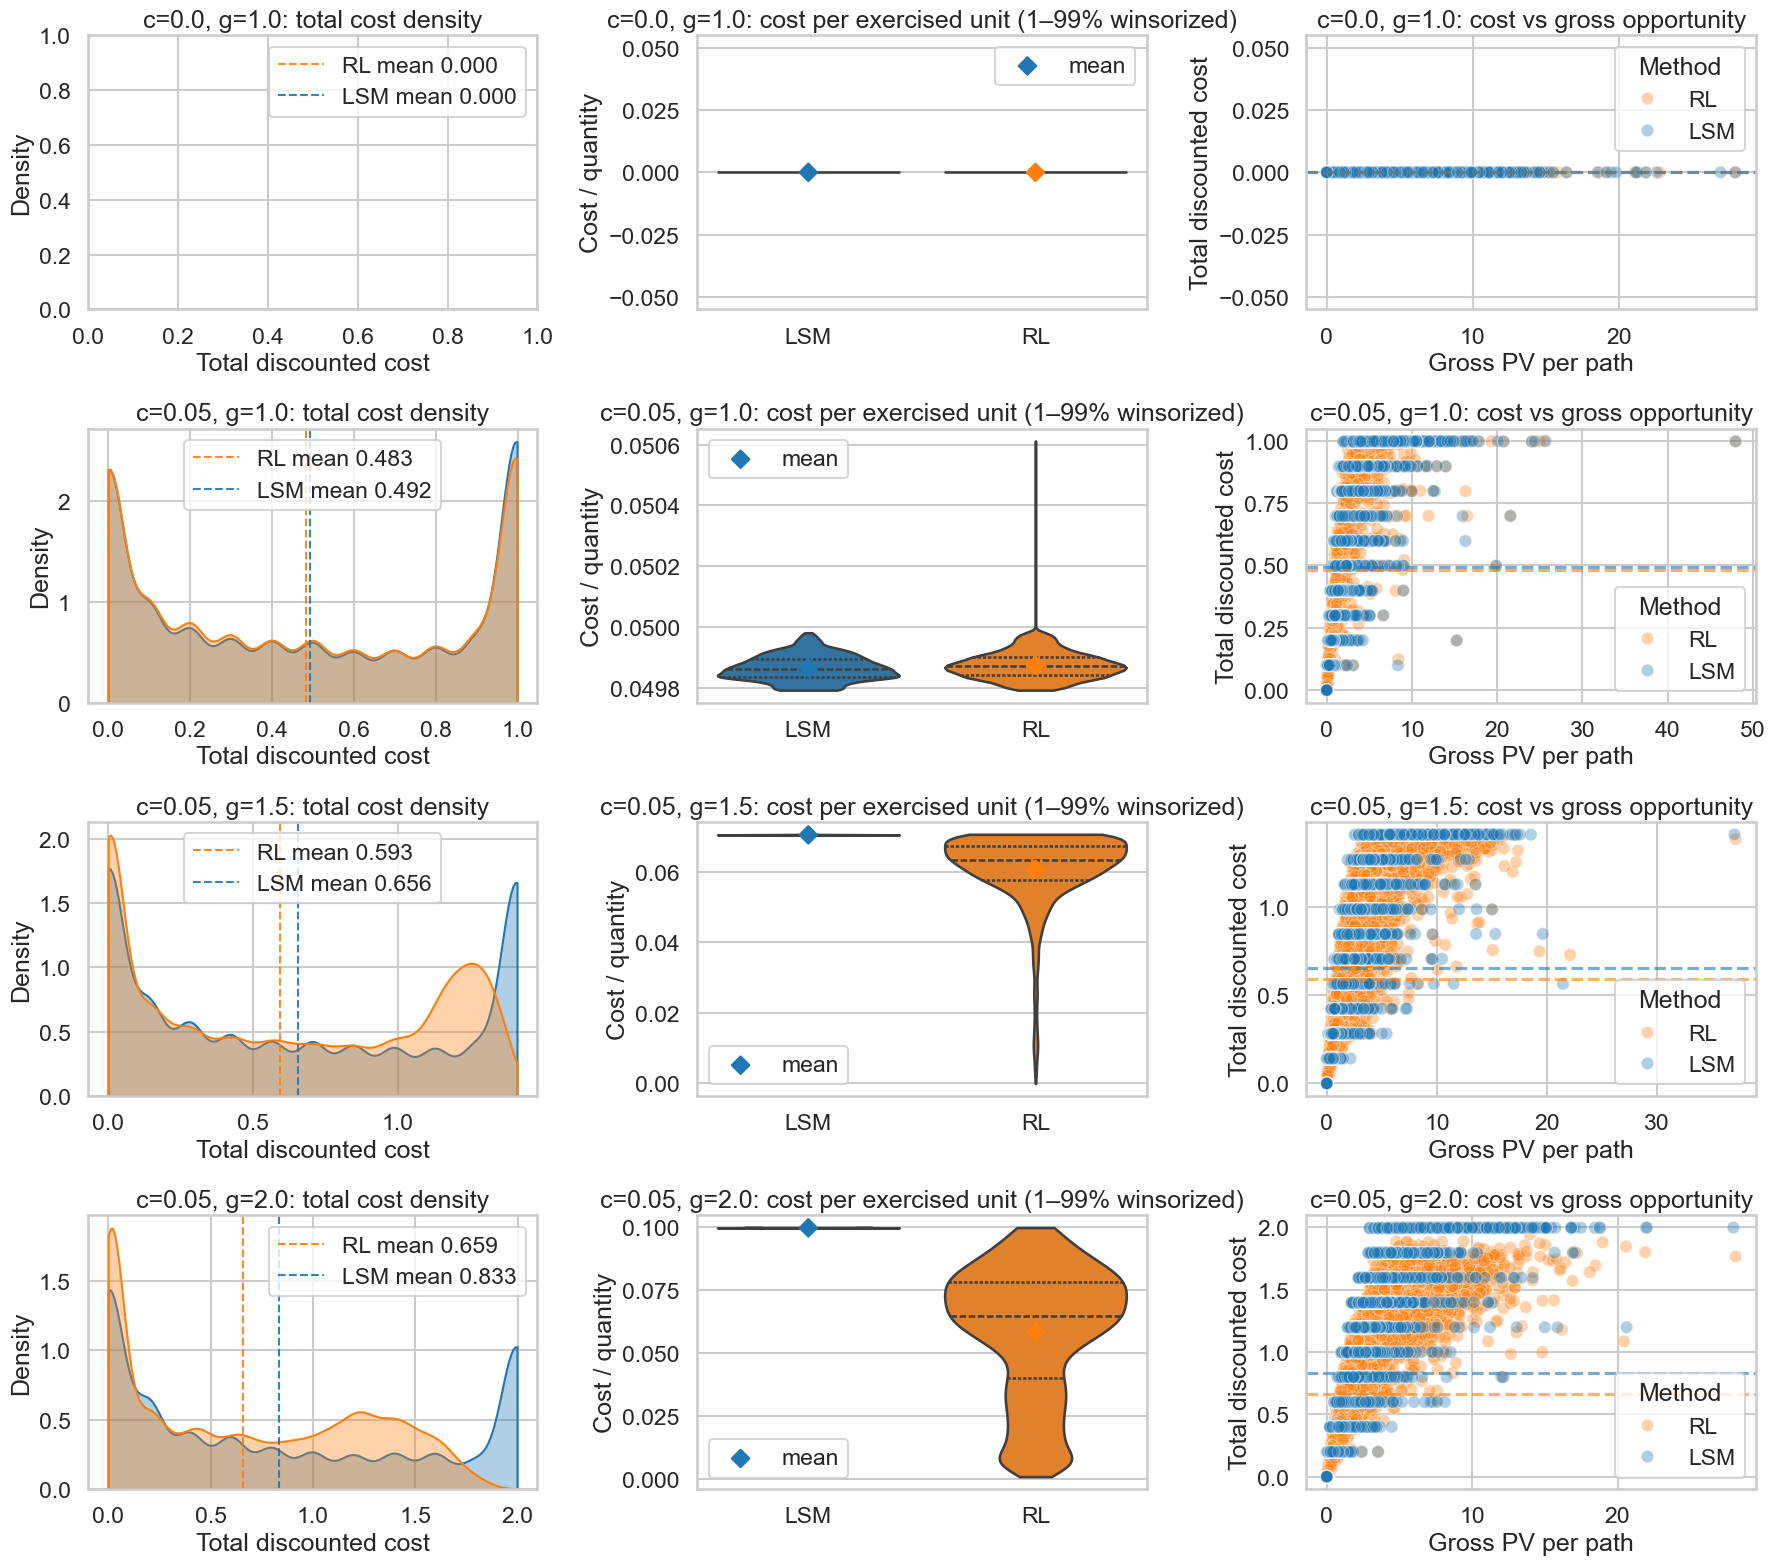

: 

: 

: 

In [ ]:

palette = {"RL": "tab:orange", "LSM": "tab:blue"}
fig, axes = plt.subplots(len(order), 3, figsize=(18, 4 * len(order)))
axes = axes.reshape(len(order), 3)

for row, lbl in enumerate(order):
    cfg_name = label_map[lbl]
    sub = path_stats.query("label == @lbl")
    cost_max = sub["PV_cost"].max()
    sns.kdeplot(
        data=sub,
        x="PV_cost",
        hue="method",
        fill=True,
        alpha=0.35,
        linewidth=1.5,
        common_norm=False,
        palette=palette,
        ax=axes[row, 0],
        bw_adjust=0.6,
        clip=(0, cost_max),
        warn_singular=False,
    )
    axes[row, 0].set_title(f"{cfg_name}: total cost density")
    axes[row, 0].set_xlabel("Total discounted cost")
    axes[row, 0].set_ylabel("Density")
    cost_means = sub.groupby("method")["PV_cost"].mean()
    for method, color in palette.items():
        val = cost_means.get(method)
        if np.isfinite(val):
            axes[row, 0].axvline(val, color=color, linestyle="--", linewidth=1.5, alpha=0.9, label=f"{method} mean {val:.3f}")
    axes[row, 0].legend()

    sns.violinplot(
        data=sub,
        x="method",
        y="cost_per_unit_clipped",
        hue="method",
        palette=palette,
        cut=0,
        inner="quartile",
        order=["LSM", "RL"],
        legend=False,
        ax=axes[row, 1],
)
    axes[row, 1].set_title(f"{cfg_name}: cost per exercised unit (1–99% winsorized)")
    axes[row, 1].set_xlabel("")
    axes[row, 1].set_ylabel("Cost / quantity")
    cpu_means = sub.groupby("method")["cost_per_unit_clipped"].mean()
    axes[row, 1].scatter([0, 1], [cpu_means.get("LSM", np.nan), cpu_means.get("RL", np.nan)], c=[palette["LSM"], palette["RL"]], s=80, marker="D", zorder=10, label="mean")
    axes[row, 1].legend()

    sns.scatterplot(
        data=sub,
        x="PV_gross",
        y="PV_cost",
        hue="method",
        palette=palette,
        alpha=0.35,
        ax=axes[row, 2],
)
    axes[row, 2].set_title(f"{cfg_name}: cost vs gross opportunity")
    axes[row, 2].set_xlabel("Gross PV per path")
    axes[row, 2].set_ylabel("Total discounted cost")
    for method, color in palette.items():
        mean_cost = sub.loc[sub["method"] == method, "PV_cost"].mean()
        axes[row, 2].axhline(mean_cost, color=color, linestyle="--", alpha=0.6)
    axes[row, 2].legend(loc="best", title="Method")

fig.tight_layout()
# savefig(fig, "cost_diagnostics_by_config")
plt.show()
plt.close(fig)

In [ ]:
del path_stats

: 

: 

: 

## Cost–reward scatter diagnostics (per config)
Adaptation of the plotly diagnostics: four small-multiple figures (one per config) with per-path reward vs cost and spot-conditioned scatter views.


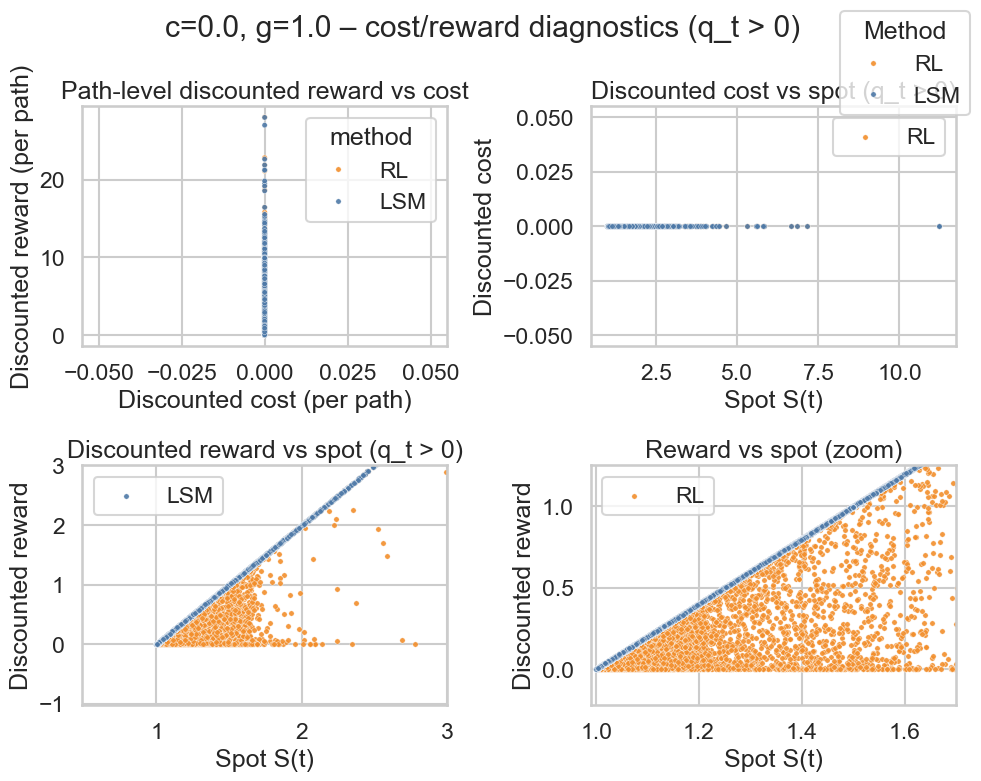

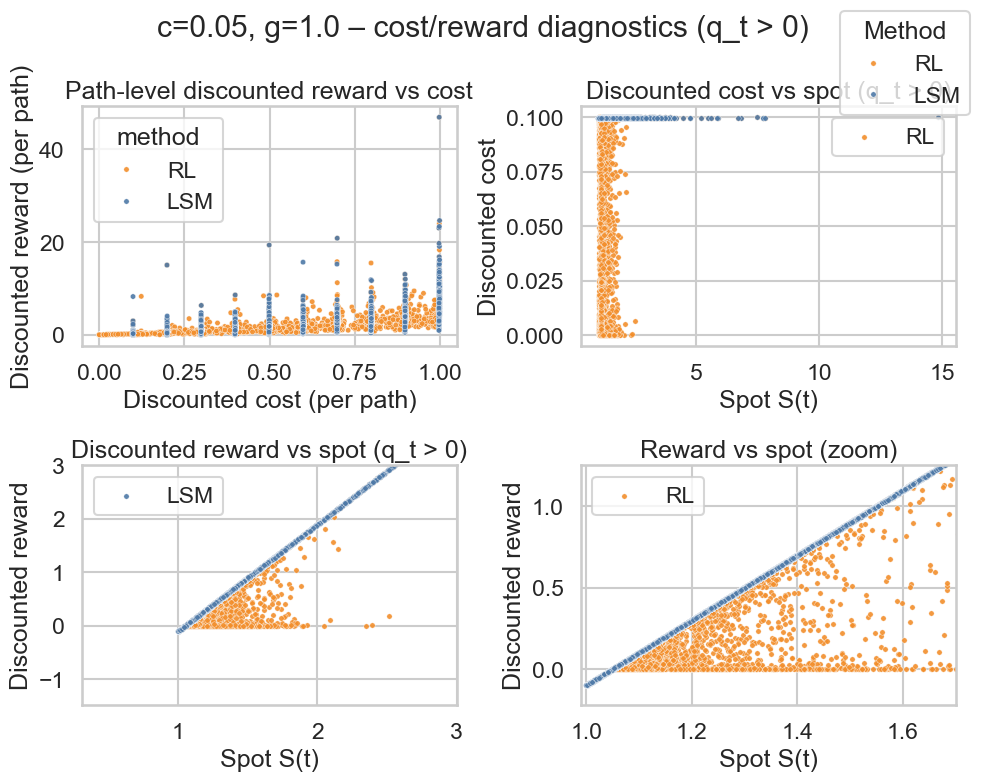

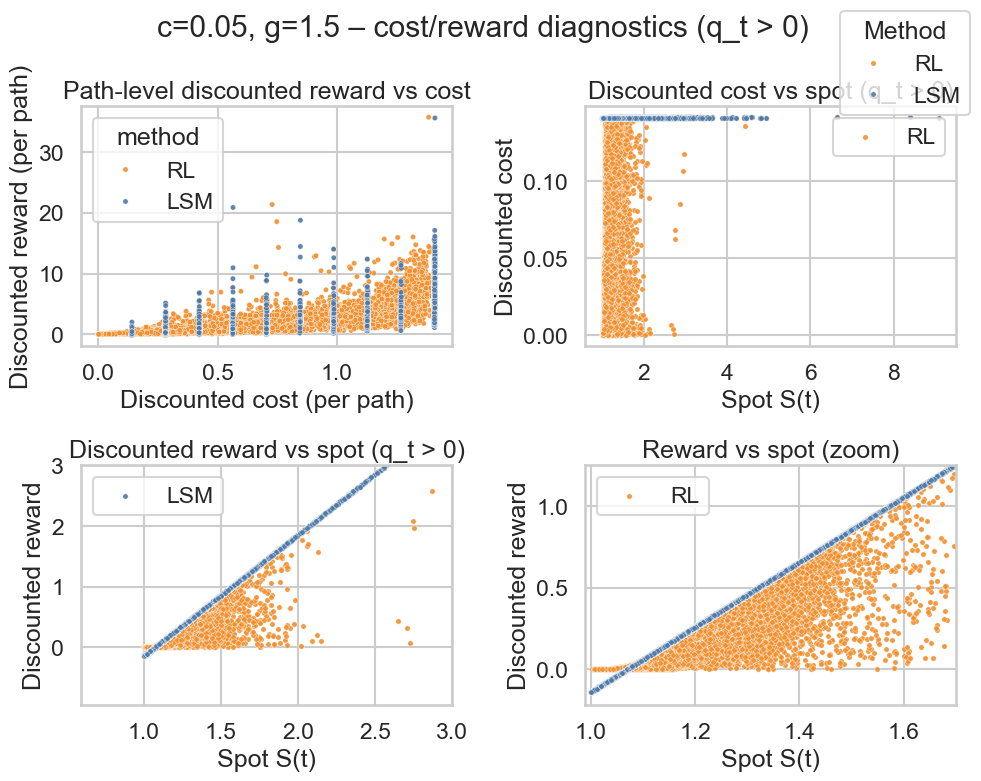

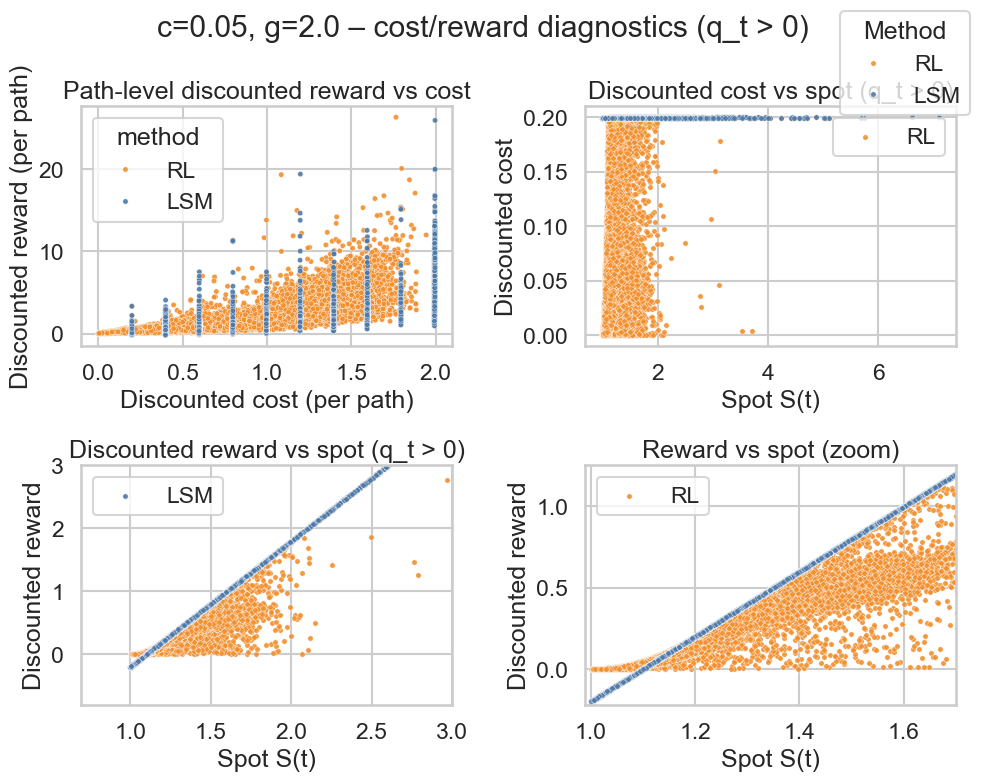

: 

: 

: 

In [ ]:


palette_diag = {"RL": "#f28e2b", "LSM": "#4e79a7"}
marker_size = 15

for data in run_data:
    label = data["spec"]["label"]
    cfg = data["cfg"]
    cfg_name = label_map[label]
    dt = cfg["maturity"] / cfg["n_rights"]

    frames = {}
    per_path = []
    for method, df_raw in (("RL", data["rl_df"]), ("LSM", data["lsm_df"])):
        df = df_raw.copy()
        df = df.query("q_t > 0")
        discount = np.exp(-cfg["risk_free_rate"] * (df["time_step"] + 1) * dt)
        if method == "RL":
            df["reward_disc"] = df["reward"]
            df["cost_disc"] = df["exercise_cost"] * discount
        else:
            df["reward_disc"] = df["payoff"] * discount
            df["cost_disc"] = df["exercise_cost"] * discount
        df["method"] = method
        frames[method] = df
        per_path.append(df.groupby("path")[['cost_disc', 'reward_disc']].sum().assign(method=method))

    path_view = pd.concat(per_path, ignore_index=True)
    fig, axes = plt.subplots(2, 2, figsize=(10, 8))

    sns.scatterplot(
        data=path_view,
        x="cost_disc",
        y="reward_disc",
        hue="method",
        palette=palette_diag,
        alpha=0.9,
        s=marker_size,
        ax=axes[0, 0],
    )
    axes[0, 0].set_title("Path-level discounted reward vs cost")
    axes[0, 0].set_xlabel("Discounted cost (per path)")
    axes[0, 0].set_ylabel("Discounted reward (per path)")

    for method, df in frames.items():
        sns.scatterplot(
            data=df,
            x="spot",
            y="cost_disc",
            color=palette_diag[method],
            alpha=0.9,
            label=method if method == "RL" else None,
            s=marker_size,
            ax=axes[0, 1],
        )
    axes[0, 1].set_title("Discounted cost vs spot (q_t > 0)")
    axes[0, 1].set_xlabel("Spot S(t)")
    axes[0, 1].set_ylabel("Discounted cost")

    for method, df in frames.items():
        sns.scatterplot(
            data=df,
            x="spot",
            y="reward_disc",
            color=palette_diag[method],
            alpha=0.9,
            label=method if method == "LSM" else None,
            s=marker_size,
            ax=axes[1, 0],
        )
    axes[1, 0].set_title("Discounted reward vs spot (q_t > 0)")
    axes[1, 0].set_xlabel("Spot S(t)")
    axes[1, 0].set_ylabel("Discounted reward")
    axes[1, 0].set_xlim(left=None, right=3.0)
    axes[1, 0].set_ylim(top=3.0)

    for method, df in frames.items():
        sns.scatterplot(
            data=df,
            x="spot",
            y="reward_disc",
            color=palette_diag[method],
            alpha=0.9,
            s=marker_size,
            ax=axes[1, 1],
            label=method if method == "RL" else None,
        )
    axes[1, 1].set_xlim(0.99, 1.70)
    axes[1, 1].set_ylim(-0.22, 1.25)
    axes[1, 1].set_title("Reward vs spot (zoom)")
    axes[1, 1].set_xlabel("Spot S(t)")
    axes[1, 1].set_ylabel("Discounted reward")

    handles, labels_leg = axes[0, 0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels_leg, loc="upper right", title="Method")
    fig.suptitle(f"{cfg_name} – cost/reward diagnostics (q_t > 0)", y=0.98)
    plt.tight_layout()
    # savefig(fig, f"diagnostics_{label}")
    plt.show()



## Exercise intensity heatmaps by moneyness (all configs)

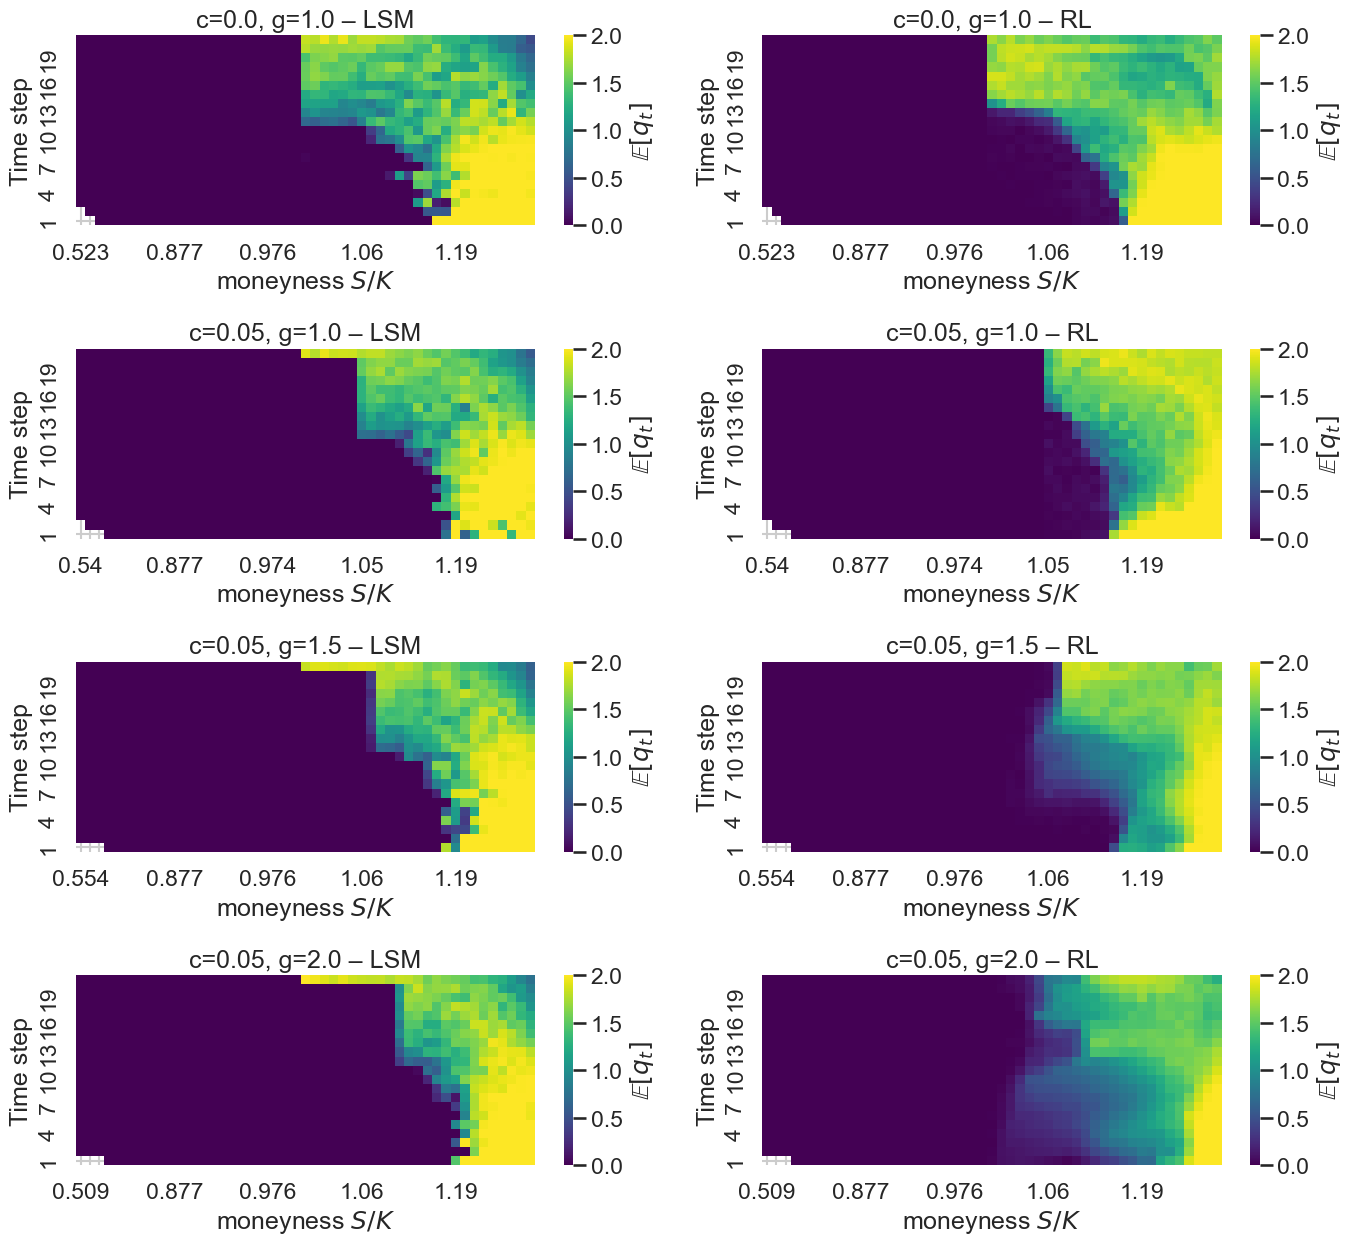

: 

: 

: 

In [ ]:


def heatmap_state(df, ax, bins, vmax=2.0, xtick_every=10):
    d = df.copy().query("time_step > 0")
    d["mny"] = d["spot"] / 1.0  # K=1
    d = d[np.isfinite(d["mny"]) & np.isfinite(d["q_t"])]
    d["mny_bin"] = pd.cut(d["mny"], bins=bins, include_lowest=True)
    pivot = d.pivot_table(index="time_step", columns="mny_bin", values="q_t", aggfunc="mean", observed=True)
    pivot = pivot.sort_index().reindex(columns=bins)
    sns.heatmap(pivot, cmap="viridis", vmin=0.0, vmax=vmax, cbar_kws={"label": r"$\mathbb{E}[q_t]$"}, ax=ax)
    ncols = pivot.shape[1]
    positions = np.arange(ncols) + 0.5
    ax.set_xticks(positions)
    mids = [(iv.left + iv.right) / 2.0 for iv in pivot.columns]
    labels = [f"{m:.3g}" if (i % xtick_every == 0) else "" for i, m in enumerate(mids)]
    ax.set_xticklabels(labels, rotation=0)
    ax.set_xlabel(r"moneyness $S/K$")
    ax.set_ylabel("Time step")
    ax.invert_yaxis()

fig, axes = plt.subplots(len(order), 2, figsize=(14, 3.2 * len(order)))
axes = axes.reshape(len(order), 2)
for row, lbl in enumerate(order):
    cfg_name = label_map[lbl]
    rl_df = next(d for d in run_data if d["spec"]["label"] == lbl)["rl_df"]
    lsm_df = next(d for d in run_data if d["spec"]["label"] == lbl)["lsm_df"]
    mny_all = pd.concat([lsm_df["spot"], rl_df["spot"]], ignore_index=True)
    cats = pd.qcut(mny_all, q=50, duplicates="drop")
    edges = np.unique(np.r_[cats.cat.categories[0].left, [c.right for c in cats.cat.categories]])
    bins = pd.IntervalIndex.from_breaks(edges)
    for col, (method, df) in enumerate([( "LSM", lsm_df), ("RL", rl_df)]):
        ax = axes[row, col]
        heatmap_state(df, ax, bins=bins, vmax=2.0, xtick_every=10)
        ax.set_title(f"{cfg_name} – {method}")
fig.tight_layout()
# savefig(fig, "heatmaps_all_configs")
plt.show()
plt.close(fig)

In [ ]:
del run_data

: 

: 

: 

## Expanded synopsis across configs

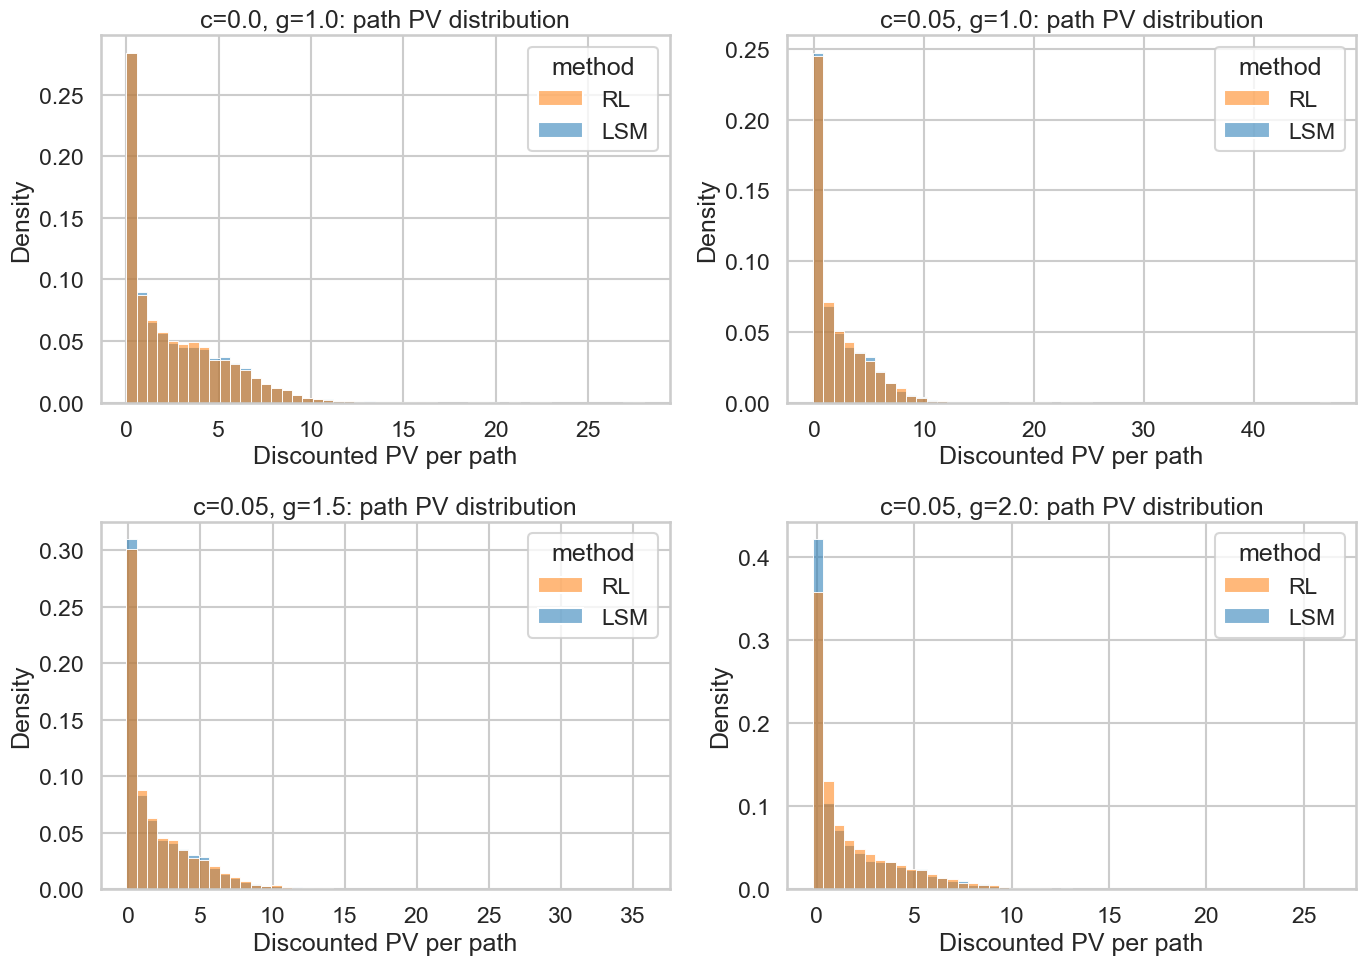

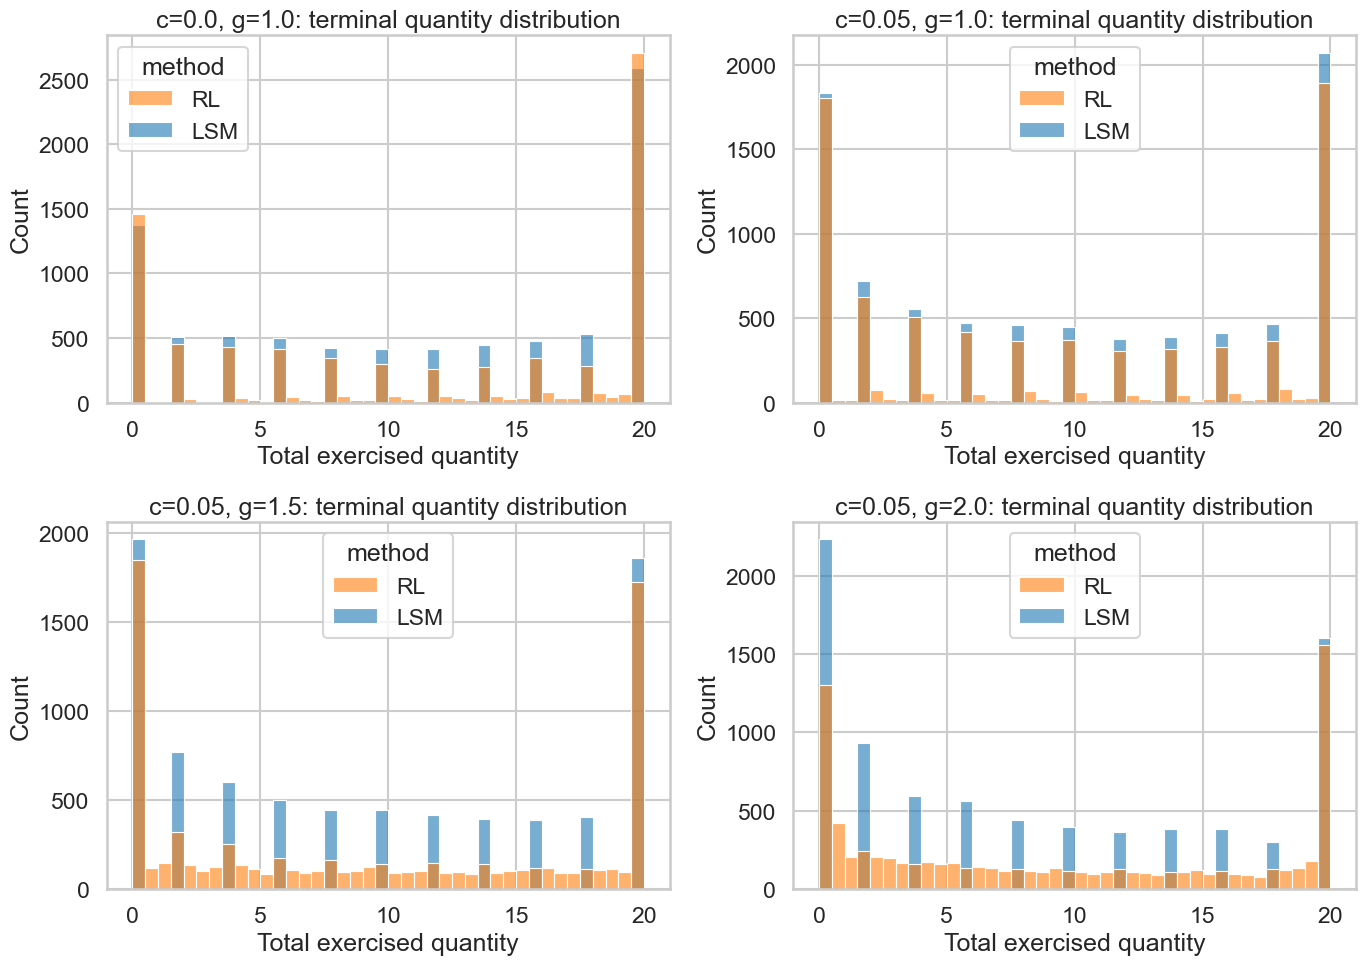

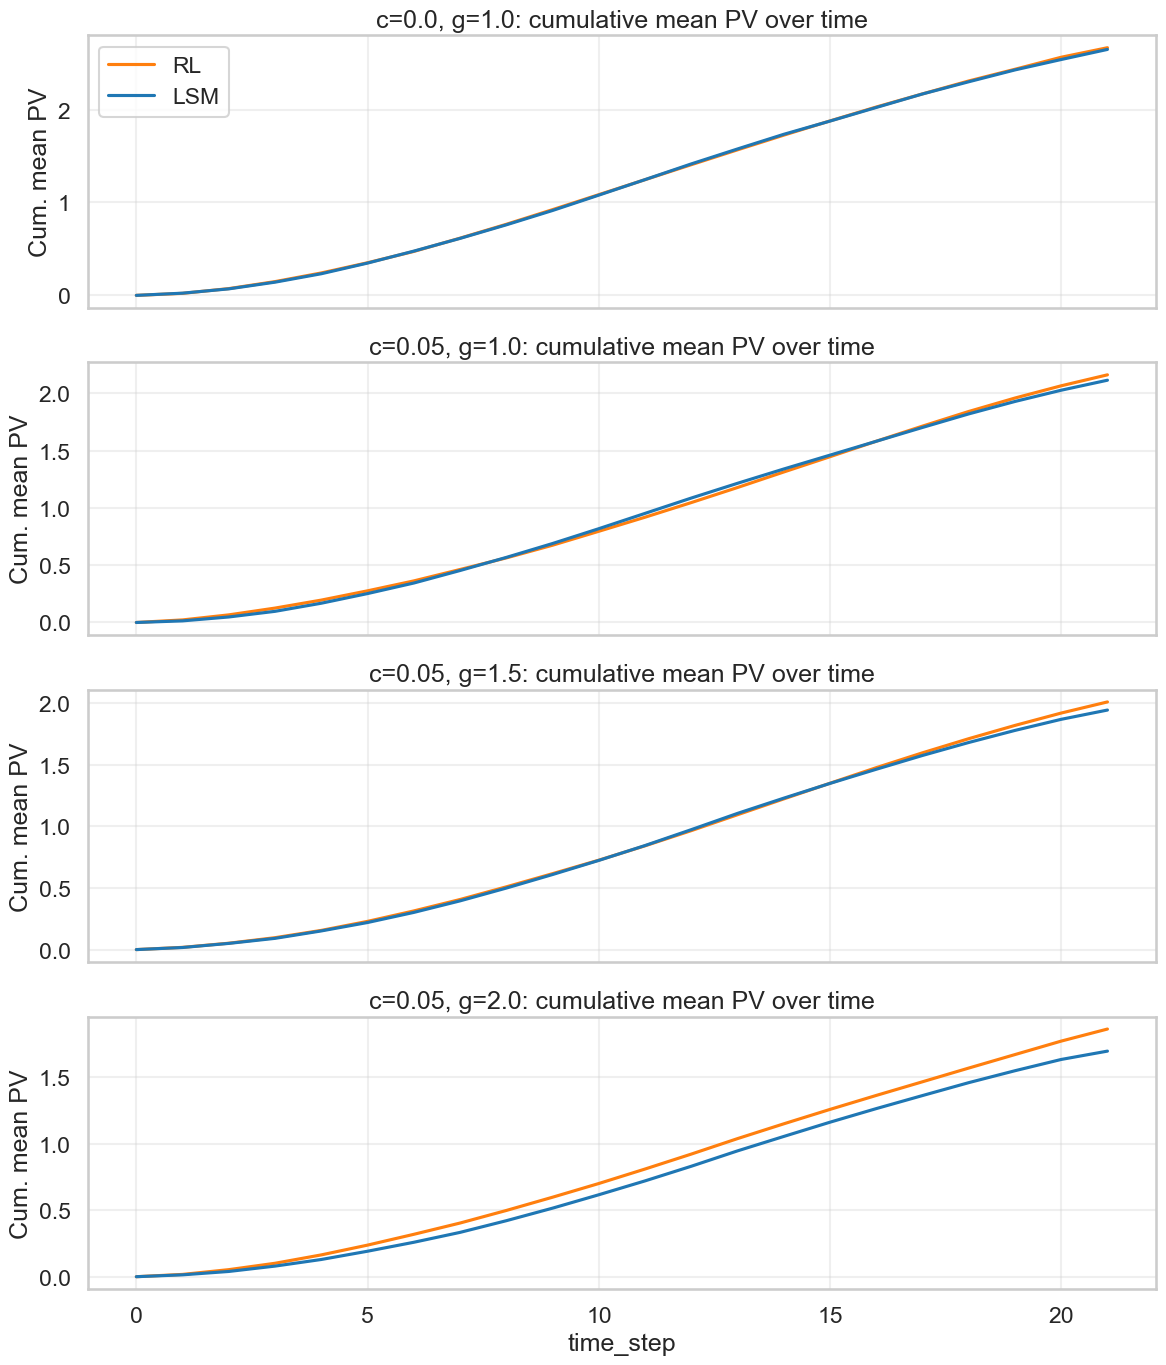

: 

: 

: 

In [ ]:
 
# Build synopsis frames for histograms and cumulative PV curves
pv_hist = (
    paths_all_df.rename(columns={"net_pv": "pv_step"})[["label", "method", "pv_step"]]
    .copy()
)
q_hist = (
    paths_all_df.rename(columns={"qty": "q_t"})[["label", "method", "q_t"]]
    .copy()
)

ts_curves = []
for spec in RUN_SPECS:
    with open(spec["config_path"]) as f:
        cfg = json.load(f)
    dt = cfg["maturity"] / cfg["n_rights"]
    for method, csv_path in (("RL", spec["rl_path"]), ("LSM", spec["lsm_path"])):
        required_cols = RL_REQUIRED if method == "RL" else LSM_REQUIRED
        df = load_eval_csv(csv_path, required_cols, f"{method} {spec['label']}")
        if method == "RL":
            net_step = df["reward"]
        else:
            discount = np.exp(-cfg["risk_free_rate"] * (df["time_step"] + 1) * dt)
            net_step = df["payoff"] * discount
        per_step = (
            pd.DataFrame({"time_step": df["time_step"], "net_step": net_step})
            .groupby("time_step")["net_step"]
            .mean()
            .sort_index()
            .cumsum()
            .reset_index()
            .rename(columns={"net_step": "cum_mean_pv"})
        )
        per_step["label"] = spec["label"]
        per_step["method"] = method
        ts_curves.append(per_step)
        del df

ts_payoff = pd.concat(ts_curves, ignore_index=True)
del ts_curves

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()
for ax, lbl in zip(axes, order):
    cfg_name = label_map[lbl]
    sub = pv_hist.query("label == @lbl")
    sns.histplot(sub, x="pv_step", hue="method", bins=50, palette=palette, ax=ax, stat="density", alpha=0.55)
    ax.set_title(f"{cfg_name}: path PV distribution")
    ax.set_xlabel("Discounted PV per path")
    ax.set_ylabel("Density")
fig.tight_layout()
plt.show()
plt.close(fig)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()
for ax, lbl in zip(axes, order):
    cfg_name = label_map[lbl]
    sub = q_hist.query("label == @lbl")
    sns.histplot(sub, x="q_t", hue="method", bins=40, palette=palette, ax=ax, alpha=0.6)
    ax.set_title(f"{cfg_name}: terminal quantity distribution")
    ax.set_xlabel("Total exercised quantity")
    ax.set_ylabel("Count")
fig.tight_layout()
plt.show()
plt.close(fig)

fig, axes = plt.subplots(len(order), 1, figsize=(12, 3.5 * len(order)), sharex=True)
if len(order) == 1:
    axes = [axes]
for ax, lbl in zip(axes, order):
    cfg_name = label_map[lbl]
    sub = ts_payoff.query("label == @lbl")
    for method, color in palette.items():
        prof = sub[sub["method"] == method]
        ax.plot(prof["time_step"], prof["cum_mean_pv"], label=method, color=color)
    ax.set_title(f"{cfg_name}: cumulative mean PV over time")
    ax.set_ylabel("Cum. mean PV")
    ax.grid(alpha=0.3)
axes[-1].set_xlabel("time_step")
axes[0].legend()
plt.tight_layout()
plt.show()
plt.close(fig)